In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pandas as pd

In [9]:
## 2. Data Loading
DATA_DIR = '../data/raw_data'

sales = pd.read_csv(f'{DATA_DIR}/analytical/sales.csv', parse_dates=['Date'])
test = pd.read_csv(f'{DATA_DIR}/analytical/sample_submission.csv', parse_dates=['Date'])
promotions = pd.read_csv(f'{DATA_DIR}/master/promotions.csv', parse_dates=['start_date', 'end_date'])
web_traffic = pd.read_csv(f'{DATA_DIR}/operational/web_traffic.csv', parse_dates=['date'])
inventory = pd.read_csv(f'{DATA_DIR}/operational/inventory.csv', parse_dates=['snapshot_date'])


CODE TRỰC QUAN HOÁ 1: TÌNH HUỐNG (MÙA VỤ & KHUYẾN MÃI)

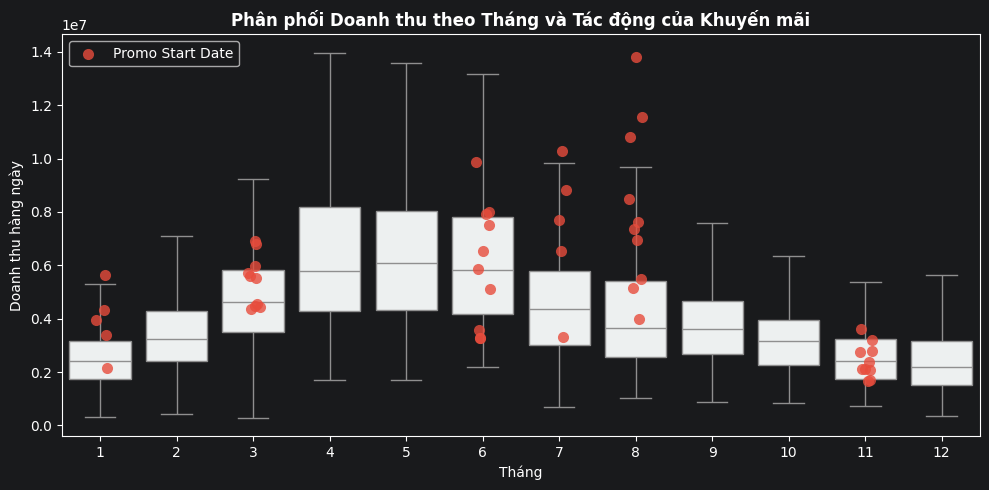

In [10]:
sales['Month'] = sales['Date'].dt.month
sales['Year'] = sales['Date'].dt.year

# Trích xuất các ngày bắt đầu khuyến mãi để đánh dấu trên biểu đồ
promo_starts = promotions['start_date'].dt.date.unique()
sales['is_promo_start'] = sales['Date'].dt.date.isin(promo_starts)

plt.figure(figsize=(10, 5))
sns.boxplot(data=sales, x='Month', y='Revenue', color='#ecf0f1', showfliers=False)

# Overlay các ngày có chương trình khuyến mãi (màu đỏ)
promo_data = sales[sales['is_promo_start']]
sns.stripplot(data=promo_data, x='Month', y='Revenue', color='#e74c3c', size=8, jitter=True, label='Promo Start Date', alpha=0.8)

plt.title('Phân phối Doanh thu theo Tháng và Tác động của Khuyến mãi', fontsize=12, fontweight='bold')
plt.xlabel('Tháng', fontsize=10)
plt.ylabel('Doanh thu hàng ngày', fontsize=10)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left')

plt.tight_layout()
plt.show()

CODE TRỰC QUAN HOÁ 2: TÌNH HUỐNG (MA TRẬN TỒN KHO)

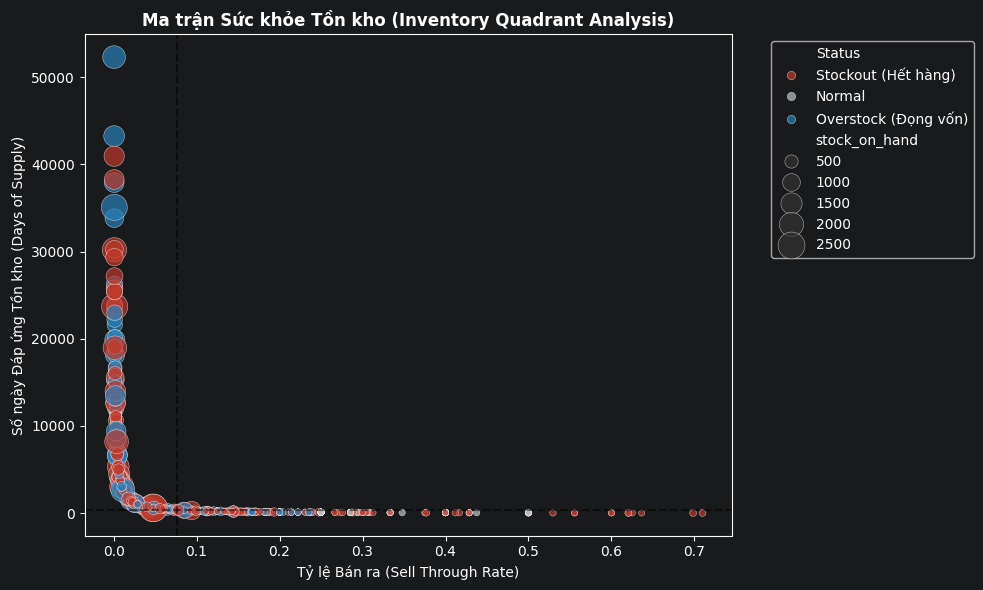

In [11]:
inv_latest = inventory.sort_values('snapshot_date').groupby('product_id').tail(1).copy()

# Phân loại trạng thái để tô màu
inv_latest['Status'] = 'Normal'
inv_latest.loc[inv_latest['overstock_flag'] == 1, 'Status'] = 'Overstock (Đọng vốn)'
inv_latest.loc[inv_latest['stockout_flag'] == 1, 'Status'] = 'Stockout (Hết hàng)'

palette = {'Normal': '#bdc3c7', 'Overstock (Đọng vốn)': '#2980b9', 'Stockout (Hết hàng)': '#c0392b'}

plt.figure(figsize=(10, 6))

sns.scatterplot(data=inv_latest,
                x='sell_through_rate',
                y='days_of_supply',
                hue='Status',
                size='stock_on_hand',
                sizes=(20, 400),
                alpha=0.7,
                palette=palette)

# Vẽ đường cắt (Reference lines) dựa trên trung vị để chia 4 góc phần tư
plt.axvline(inv_latest['sell_through_rate'].median(), color='k', linestyle='--', alpha=0.5)
plt.axhline(inv_latest['days_of_supply'].median(), color='k', linestyle='--', alpha=0.5)

plt.title('Ma trận Sức khỏe Tồn kho (Inventory Quadrant Analysis)', fontsize=12, fontweight='bold')
plt.xlabel('Tỷ lệ Bán ra (Sell Through Rate)', fontsize=10)
plt.ylabel('Số ngày Đáp ứng Tồn kho (Days of Supply)', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Chỉ số dẫn xuất (Leading Indicators): Tương quan giữa Lưu lượng truy cập (Web Traffic) và Doanh thu.

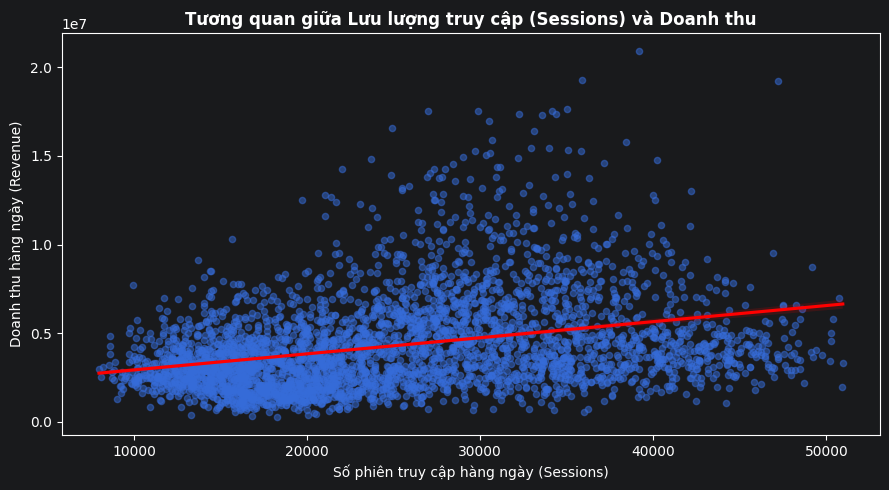

In [12]:
# Merge dữ liệu theo ngày
df_merged = pd.merge(sales, web_traffic, left_on='Date', right_on='date', how='inner')

plt.figure(figsize=(9, 5))

# Vẽ Scatter plot kèm đường hồi quy
sns.regplot(data=df_merged, x='sessions', y='Revenue', scatter_kws={'alpha':0.5, 's':20}, line_kws={'color':'red'})

plt.title('Tương quan giữa Lưu lượng truy cập (Sessions) và Doanh thu', fontsize=12, fontweight='bold')
plt.xlabel('Số phiên truy cập hàng ngày (Sessions)', fontsize=10)
plt.ylabel('Doanh thu hàng ngày (Revenue)', fontsize=10)

plt.tight_layout()
plt.show()